<a href="https://colab.research.google.com/github/kh1z3r/chicago-food-inspections/blob/fairlearn-per-zip/food_inspections.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
CSV_PATH = '/content/drive/MyDrive/AI4ALL/Food_Inspections_20260715.csv'
df = pd.read_csv(CSV_PATH, dtype={'Zip': 'string', 'License #': 'string'})
print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(312996, 17)


,Inspection ID,DBA Name,AKA Name,License #,Facility Type,Risk,Address,City,State,Zip,Inspection Date,Inspection Type,Results,Violations,Latitude,Longitude,Location
0,2639625,EGGHOLIC/ TACO PROS,EGGHOLIC/ TACO PROS,2632312,Restaurant,Risk 1 (High),833 W CHICAGO AVE,CHICAGO,IL,60642,07/13/2026,Canvass,Fail,2. CITY OF CHICAGO FOOD SERVICE SANITATION CER...,41.896266,-87.648962,"(41.89626550998868, -87.6489619254971)"
1,2639623,CAFE GIMME,CAFE GIMME,3069216,Restaurant,Risk 1 (High),2115 N DAMEN AVE,CHICAGO,IL,60647,07/13/2026,License Re-Inspection,Pass,NaN,41.920180,-87.677563,"(41.92018027428698, -87.67756275049621)"
2,2639634,HUCK FINN,HUCK FINN,6476,Restaurant,Risk 1 (High),6650 S PULASKI RD,CHICAGO,IL,60629,07/13/2026,Complaint,Pass,49. NON-FOOD/FOOD CONTACT SURFACES CLEAN - Com...,41.771650,-87.722730,"(41.7716501459201, -87.72272964628908)"
3,2639645,ATTOCK SUBMARINE,ATTOCK SUBMARINE,3090646,Restaurant,Risk 2 (Medium),3006 E 92ND ST,Chicago,IL,60617,07/13/2026,License Re-Inspection,Pass w/ Conditions,"3. MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL E...",41.728365,-87.550897,"(41.72836464185542, -87.55089731409362)"
4,2639635,BITTERSWEET,BITTERSWEET,3045838,Restaurant,Risk 1 (High),850 W MONROE ST,CHICAGO,IL,60607,07/13/2026,Complaint Re-Inspection,Pass,NaN,41.880565,-87.649361,"(41.880565045499175, -87.6493614181914)"


In [4]:
#Target: We predict the Results column as Fail = 1 vs not-Fail = 0 (Pass and Pass w/ Conditions = 0; we drop non-decision outcomes like Out of Business and No Entry).

In [5]:
import numpy as np

# "Results" is text (Pass, Fail, ...). Convert it to a 0/1 target the model can learn.
# Normalize the text first so spacing/case differences don't create duplicate categories.
r = df["Results"].str.strip().str.upper()

# Fail = 1; Pass and Pass w/ Conditions = 0. Any other result (Out of Business, No Entry, Not Ready)
# isn't a real pass/fail decision, so map it to NaN here and drop it on the next line.
fail_map = {"FAIL": 1, "PASS": 0, "PASS W/ CONDITIONS": 0}
df["y"] = r.map(fail_map)

before = len(df)
df = df[df["y"].notna()].copy()      # keep only genuine pass/fail rows
df["y"] = df["y"].astype(int)

print(f"Rows: {before} -> {len(df)}")
print(f"Fail rate: {df['y'].mean():.1%}")

Rows: 312996 -> 268713
Fail rate: 22.4%


In [6]:
# Use only information available BEFORE an inspection. We deliberately exclude the Violations column,
# because it's recorded during the inspection - feeding it in would leak the answer to the model.

# Facility Type has 527 messy values. Keep the 15 most common, lump the rest into "OTHER",
# and fill blanks with the most common value.
ft = df["Facility Type"].astype("string").str.strip().str.upper()
ft = ft.fillna(ft.mode(dropna=True)[0])
top15 = ft.value_counts().head(15).index
df["FacilityType_g"] = ft.where(ft.isin(top15), "OTHER")

# Inspection Type has 111 values. Collapse them into a few families. This feature matters because
# Complaint and Re-Inspection visits target already-flagged places, so it lets the model tell
# "inspected more often" apart from "actually worse".
it = df["Inspection Type"].astype("string").str.strip().str.upper().fillna("OTHER")
def fam(s):
    if "RE-INSPECTION" in s or "REINSPECTION" in s: return "Re-Inspection"
    if "COMPLAINT" in s: return "Complaint"
    if "CANVASS" in s:   return "Canvass"
    if "LICENSE" in s:   return "License"
    return "Other"
df["InspType_g"] = it.map(fam)

# Risk has three real levels plus a few blank / "All" rows. Drop those rows.
rk = df["Risk"].astype("string").str.strip()
valid_risk = ["Risk 1 (High)", "Risk 2 (Medium)", "Risk 3 (Low)"]
df = df[rk.isin(valid_risk)].copy()
df["Risk_g"] = df["Risk"].str.strip()

# Zip is the location feature. Drop blank zips and keep it as text - a ZIP is a category,
# not a quantity (60614 isn't "greater than" 60612).
df = df[df["Zip"].notna() & (df["Zip"].str.strip() != "")].copy()
df["Zip"] = df["Zip"].str.strip()

# License # identifies the establishment; we'll use it to group the split. Drop blank/0 licenses,
# since a missing group would silently merge many unrelated establishments into one.
lic = df["License #"].fillna("0").str.strip()
df = df[(lic != "") & (lic != "0")].copy()
df["lic"] = df["License #"].str.strip()

print("Rows after cleaning:", len(df), "| distinct licenses:", df["lic"].nunique())
print(df["InspType_g"].value_counts())

Rows after cleaning: 267949 | distinct licenses: 43422
InspType_g
Canvass          130712
Re-Inspection     59344
License           37339
Complaint         37028
Other              3526
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import GroupShuffleSplit

# The same restaurant appears many times. If some of its inspections go to training and others to
# testing, the model can memorize that specific place and post an inflated score. GroupShuffleSplit
# keeps every inspection of one license entirely in train OR test - never both.
FEATURES = ["FacilityType_g", "Risk_g", "InspType_g", "Zip"]
X = df[FEATURES]
y = df["y"].values
groups = df["lic"].values                 # group = the establishment's license number

# random_state=42 fixes the split so every teammate gets identical train/test rows.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
ytr, yte = y[train_idx], y[test_idx]

# Sanity check: no license should appear in both sets.
overlap = set(groups[train_idx]) & set(groups[test_idx])
print(f"Train {len(Xtr)} | Test {len(Xte)} | overlapping licenses: {len(overlap)} (must be 0)")

Train 214479 | Test 53470 | overlapping licenses: 0 (must be 0)


In [8]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

# The features are text categories, so we one-hot encode them (one 0/1 column per category).
# Keeping the encoder inside a Pipeline means it's fit on the training data only, then applied to test.
def make_pipe(model, feats):
    enc = ColumnTransformer([("oh", OneHotEncoder(handle_unknown="ignore"), feats)])
    return Pipeline([("enc", enc), ("model", model)])

# We score on RECALL of failures (the share of real fails we catch), not overall accuracy: since ~78%
# of inspections pass, a model that always says "Pass" is 78% accurate yet catches nothing useful.
def report(name, ypred):
    print(f"\n[{name}]  recall={recall_score(yte, ypred, zero_division=0):.3f} "
          f"precision={precision_score(yte, ypred, zero_division=0):.3f} "
          f"F1={f1_score(yte, ypred, zero_division=0):.3f}")
    print("confusion [[TN FP][FN TP]]:\n", confusion_matrix(yte, ypred))

# Baseline: always predict Pass. Catches zero failures by design - the bar our models must clear.
report("Naive baseline (always Pass)", np.zeros_like(yte))

# Logistic regression: simple and explainable. class_weight="balanced" weights the rare failures
# more heavily so the model doesn't just ignore them.
logreg = make_pipe(LogisticRegression(class_weight="balanced", max_iter=1000), FEATURES)
logreg.fit(Xtr, ytr)
report("Logistic Regression", logreg.predict(Xte))

# Random forest: many decision trees combined - usually more accurate and can rank feature importance.
# n_estimators=150 runs in ~1-2 min on Colab; raise to 300 for the final version.
rf = make_pipe(RandomForestClassifier(class_weight="balanced", n_estimators=150,
                                      random_state=42, n_jobs=-1), FEATURES)
rf.fit(Xtr, ytr)
report("Random Forest", rf.predict(Xte))


[Naive baseline (always Pass)]  recall=0.000 precision=0.000 F1=0.000
confusion [[TN FP][FN TP]]:
 [[41489     0]
 [11981     0]]

[Logistic Regression]  recall=0.715 precision=0.294 F1=0.417
confusion [[TN FP][FN TP]]:
 [[20966 20523]
 [ 3414  8567]]

[Random Forest]  recall=0.663 precision=0.302 F1=0.415
confusion [[TN FP][FN TP]]:
 [[23135 18354]
 [ 4040  7941]]


In [9]:
# Use only information available BEFORE an inspection. We deliberately exclude the Violations column,
# because it's recorded during the inspection - feeding it in would leak the answer to the model.

# Facility Type has 527 messy values. Keep the 15 most common, lump the rest into "OTHER",
# and fill blanks with the most common value.
ft = df["Facility Type"].astype("string").str.strip().str.upper()
ft = ft.fillna(ft.mode(dropna=True)[0])
top15 = ft.value_counts().head(15).index
df["FacilityType_g"] = ft.where(ft.isin(top15), "OTHER")

# Inspection Type has 111 values. Collapse them into a few families. This feature matters because
# Complaint and Re-Inspection visits target already-flagged places, so it lets the model tell
# "inspected more often" apart from "actually worse".
it = df["Inspection Type"].astype("string").str.strip().str.upper().fillna("OTHER")
def fam(s):
    if "RE-INSPECTION" in s or "REINSPECTION" in s: return "Re-Inspection"
    if "COMPLAINT" in s: return "Complaint"
    if "CANVASS" in s:   return "Canvass"
    if "LICENSE" in s:   return "License"
    return "Other"
df["InspType_g"] = it.map(fam)

# Risk has three real levels plus a few blank / "All" rows. Drop those rows.
rk = df["Risk"].astype("string").str.strip()
valid_risk = ["Risk 1 (High)", "Risk 2 (Medium)", "Risk 3 (Low)"]
df = df[rk.isin(valid_risk)].copy()
df["Risk_g"] = df["Risk"].str.strip()

# Zip is the location feature. Drop blank zips and keep it as text - a ZIP is a category,
# not a quantity (60614 isn't "greater than" 60612).
df = df[df["Zip"].notna() & (df["Zip"].str.strip() != "")].copy()
df["Zip"] = df["Zip"].str.strip()

# License # identifies the establishment; we'll use it to group the split. Drop blank/0 licenses,
# since a missing group would silently merge many unrelated establishments into one.
lic = df["License #"].fillna("0").str.strip()
df = df[(lic != "") & (lic != "0")].copy()
df["lic"] = df["License #"].str.strip()

print("Rows after cleaning:", len(df), "| distinct licenses:", df["lic"].nunique())
print(df["InspType_g"].value_counts())

Rows after cleaning: 267949 | distinct licenses: 43422
InspType_g
Canvass          130712
Re-Inspection     59344
License           37339
Complaint         37028
Other              3526
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import GroupShuffleSplit

# The same restaurant appears many times. If some of its inspections go to training and others to
# testing, the model can memorize that specific place and post an inflated score. GroupShuffleSplit
# keeps every inspection of one license entirely in train OR test - never both.
FEATURES = ["FacilityType_g", "Risk_g", "InspType_g", "Zip"]
X = df[FEATURES]
y = df["y"].values
groups = df["lic"].values                 # group = the establishment's license number

# random_state=42 fixes the split so every teammate gets identical train/test rows.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
ytr, yte = y[train_idx], y[test_idx]

# Sanity check: no license should appear in both sets.
overlap = set(groups[train_idx]) & set(groups[test_idx])
print(f"Train {len(Xtr)} | Test {len(Xte)} | overlapping licenses: {len(overlap)} (must be 0)")

Train 214479 | Test 53470 | overlapping licenses: 0 (must be 0)


In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

# The features are text categories, so we one-hot encode them (one 0/1 column per category).
# Keeping the encoder inside a Pipeline means it's fit on the training data only, then applied to test.
def make_pipe(model, feats):
    enc = ColumnTransformer([("oh", OneHotEncoder(handle_unknown="ignore"), feats)])
    return Pipeline([("enc", enc), ("model", model)])

# We score on RECALL of failures (the share of real fails we catch), not overall accuracy: since ~78%
# of inspections pass, a model that always says "Pass" is 78% accurate yet catches nothing useful.
def report(name, ypred):
    print(f"\n[{name}]  recall={recall_score(yte, ypred, zero_division=0):.3f} "
          f"precision={precision_score(yte, ypred, zero_division=0):.3f} "
          f"F1={f1_score(yte, ypred, zero_division=0):.3f}")
    print("confusion [[TN FP][FN TP]]:\n", confusion_matrix(yte, ypred))

# Baseline: always predict Pass. Catches zero failures by design - the bar our models must clear.
report("Naive baseline (always Pass)", np.zeros_like(yte))

# Logistic regression: simple and explainable. class_weight="balanced" weights the rare failures
# more heavily so the model doesn't just ignore them.
logreg = make_pipe(LogisticRegression(class_weight="balanced", max_iter=1000), FEATURES)
logreg.fit(Xtr, ytr)
report("Logistic Regression", logreg.predict(Xte))

# Random forest: many decision trees combined - usually more accurate and can rank feature importance.
# n_estimators=150 runs in ~1-2 min on Colab; raise to 300 for the final version.
rf = make_pipe(RandomForestClassifier(class_weight="balanced", n_estimators=150,
                                      random_state=42, n_jobs=-1), FEATURES)
rf.fit(Xtr, ytr)
report("Random Forest", rf.predict(Xte))


[Naive baseline (always Pass)]  recall=0.000 precision=0.000 F1=0.000
confusion [[TN FP][FN TP]]:
 [[41489     0]
 [11981     0]]

[Logistic Regression]  recall=0.715 precision=0.294 F1=0.417
confusion [[TN FP][FN TP]]:
 [[20966 20523]
 [ 3414  8567]]

[Random Forest]  recall=0.663 precision=0.302 F1=0.415
confusion [[TN FP][FN TP]]:
 [[23135 18354]
 [ 4040  7941]]


Drop in Fail-recall when shuffled (higher = more important):
InspType_g        0.1165
Zip               0.0666
FacilityType_g    0.0646
Risk_g            0.0384


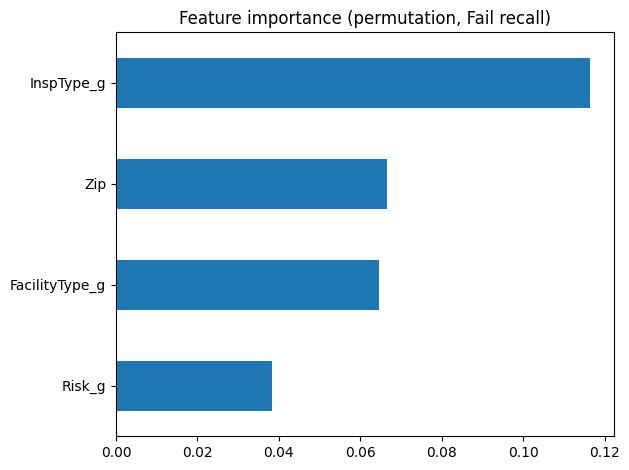

In [12]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Permutation importance shows how much the model leans on each feature: shuffle one feature's values
# in the test set and measure how far Fail-recall drops. A bigger drop means that feature mattered more.
# We shuffle the original column (before encoding), so each feature - including all the ZIP columns
# together - is measured as one group. We sample 15k test rows to keep it fast.
samp = min(15000, len(Xte))
si = np.random.RandomState(42).choice(len(Xte), samp, replace=False)
pi = permutation_importance(rf, Xte.iloc[si], yte[si], scoring="recall",
                            n_repeats=5, random_state=42, n_jobs=-1)

imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values(ascending=False)
print("Drop in Fail-recall when shuffled (higher = more important):")
print(imp.round(4).to_string())

imp.sort_values().plot.barh()
plt.title("Feature importance (permutation, Fail recall)")
plt.tight_layout(); plt.show()

In [13]:
from sklearn.metrics import average_precision_score

# ── Does the model actually use the neighborhood? (with-ZIP vs without-ZIP) ──
# We train the same Random Forest twice on the identical train/test split: once with Zip
# as a feature, once with it removed. If dropping Zip barely changes performance, the model
# is mostly leaning on the restaurant's own attributes (facility type, risk, inspection type) -
# a good sign for fairness. If performance drops a lot, the model is leaning on neighborhood.
#
# We compare using PR-AUC (average precision), not recall alone. Recall by itself is
# misleading here: dropping a feature can shift the recall/precision trade-off in either
# direction at a fixed 0.5 threshold, without changing how good the model actually is.
# PR-AUC summarizes performance across all thresholds, so it isolates whether Zip is
# genuinely informative rather than just moving where the threshold happens to cut.

FEATURES_NO_ZIP = [f for f in FEATURES if f != "Zip"]

rf_with_zip = make_pipe(
    RandomForestClassifier(class_weight="balanced", n_estimators=150, random_state=42, n_jobs=-1),
    FEATURES
)
rf_with_zip.fit(Xtr[FEATURES], ytr)

rf_no_zip = make_pipe(
    RandomForestClassifier(class_weight="balanced", n_estimators=150, random_state=42, n_jobs=-1),
    FEATURES_NO_ZIP
)
rf_no_zip.fit(Xtr[FEATURES_NO_ZIP], ytr)

# Probability of "Fail" (class 1) for each restaurant, from each model
proba_with_zip = rf_with_zip.predict_proba(Xte[FEATURES])[:, 1]
proba_no_zip   = rf_no_zip.predict_proba(Xte[FEATURES_NO_ZIP])[:, 1]

pr_auc_with_zip = average_precision_score(yte, proba_with_zip)
pr_auc_no_zip   = average_precision_score(yte, proba_no_zip)

print(f"PR-AUC WITH Zip:    {pr_auc_with_zip:.4f}")
print(f"PR-AUC WITHOUT Zip: {pr_auc_no_zip:.4f}")
print(f"Change: {pr_auc_no_zip - pr_auc_with_zip:+.4f}")

# How many individual predictions flip (Fail <-> not-Fail at the standard 0.5 cutoff)
# when Zip is removed - a second, more concrete way to see how much Zip is driving decisions.
pred_with_zip = (proba_with_zip >= 0.5).astype(int)
pred_no_zip   = (proba_no_zip >= 0.5).astype(int)
n_flipped = (pred_with_zip != pred_no_zip).sum()

print(f"\nPredictions that flip when Zip is dropped: {n_flipped} / {len(yte)} "
      f"({n_flipped/len(yte):.1%})")

PR-AUC WITH Zip:    0.3321
PR-AUC WITHOUT Zip: 0.3106
Change: -0.0215

Predictions that flip when Zip is dropped: 13522 / 53470 (25.3%)


In [14]:
import pandas as pd

# ── ZIP-level flip breakdown ──
# For each restaurant in the test set, we know: its actual ZIP, whether it truly failed,
# and how it was predicted with vs. without Zip in the model. Grouping by ZIP lets us see
# whether the 24.6% of flipped predictions are spread evenly across the city, or concentrated
# in specific neighborhoods - and whether Zip is systematically pushing predictions up
# (more flagged as Fail) or down (fewer flagged) in particular areas.

flip_df = pd.DataFrame({
    "Zip": Xte["Zip"].values,
    "y_true": yte,
    "pred_with_zip": pred_with_zip,
    "pred_no_zip": pred_no_zip,
})

# A "flip" is any restaurant whose prediction changes when Zip is removed.
flip_df["flipped"] = flip_df["pred_with_zip"] != flip_df["pred_no_zip"]

# Direction of the flip matters: does adding Zip push MORE restaurants toward "predicted Fail"
# in this area (no_zip=0 -> with_zip=1), or FEWER (no_zip=1 -> with_zip=0)?
flip_df["flip_up"]   = (flip_df["pred_no_zip"] == 0) & (flip_df["pred_with_zip"] == 1)  # Zip made it worse
flip_df["flip_down"] = (flip_df["pred_no_zip"] == 1) & (flip_df["pred_with_zip"] == 0)  # Zip made it better

# Aggregate per ZIP. Only keep ZIPs with a reasonable sample size in the test set so we're not
# reading noise into a ZIP that only had 3 restaurants.
zip_summary = flip_df.groupby("Zip").agg(
    n_test=("y_true", "size"),
    true_fail_rate=("y_true", "mean"),
    flip_rate=("flipped", "mean"),
    flip_up_rate=("flip_up", "mean"),    # Zip is pushing predictions toward MORE scrutiny here
    flip_down_rate=("flip_down", "mean"),  # Zip is pushing predictions toward LESS scrutiny here
).reset_index()

zip_summary = zip_summary[zip_summary["n_test"] >= 30].copy()  # drop tiny/noisy ZIPs
zip_summary = zip_summary.sort_values("flip_rate", ascending=False)

print("ZIP codes with the highest flip rates (Zip most changes predictions here):")
print(zip_summary.head(15).round(3).to_string(index=False))

print("\nCitywide averages, for comparison:")
print(f"Mean flip rate across ZIPs: {zip_summary['flip_rate'].mean():.3f}")
print(f"Mean flip_up rate:          {zip_summary['flip_up_rate'].mean():.3f}")
print(f"Mean flip_down rate:        {zip_summary['flip_down_rate'].mean():.3f}")

# Does the flip rate correlate with the true fail rate? If Zip mostly flips predictions in
# ZIPs that already have high true failure rates, that's more defensible (Zip may be a
# reasonable proxy for real risk). If it flips predictions in LOW true-fail-rate ZIPs, that's
# the concerning case - Zip could be inflating scrutiny somewhere without real cause.
corr = zip_summary["flip_rate"].corr(zip_summary["true_fail_rate"])
print(f"\nCorrelation between flip_rate and true_fail_rate across ZIPs: {corr:.3f}")

ZIP codes with the highest flip rates (Zip most changes predictions here):
  Zip  n_test  true_fail_rate  flip_rate  flip_up_rate  flip_down_rate
60655     212           0.165      0.698         0.047           0.651
60638     667           0.153      0.636         0.000           0.636
60661     721           0.186      0.634         0.004           0.630
60634    1234           0.190      0.629         0.009           0.620
60604     394           0.147      0.627         0.000           0.627
60601     848           0.152      0.624         0.007           0.617
60606     828           0.140      0.623         0.001           0.622
60646     382           0.162      0.613         0.024           0.589
60602     374           0.201      0.602         0.013           0.588
60666     795           0.126      0.580         0.000           0.580
60611    1696           0.165      0.577         0.002           0.575
60629    1106           0.205      0.549         0.005           0.543
60

In [15]:
!pip install fairlearn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 3.9 MB/s eta 0:00:00


In [16]:
from fairlearn.metrics import MetricFrame, false_positive_rate, false_negative_rate

# Use the with-Zip model's predictions (pred_with_zip), since that's the actual model in question —
# this is a different question from task 1's flip analysis, so don't reuse pred_no_zip here.

mf = MetricFrame(
    metrics={"fpr": false_positive_rate, "fnr": false_negative_rate},
    y_true=yte,
    y_pred=pred_with_zip,
    sensitive_features=Xte["Zip"]
)

zip_fairness = mf.by_group.reset_index()
zip_fairness.columns = ["Zip", "fpr", "fnr"]

# attach test-set counts so we can filter out tiny/noisy ZIPs
counts = pd.Series(Xte["Zip"].values).value_counts().rename("n_test")
zip_fairness = zip_fairness.merge(counts, left_on="Zip", right_index=True)

zip_fairness = zip_fairness[zip_fairness["n_test"] >= 100].copy()
zip_fairness = zip_fairness.sort_values("fpr", ascending=False)

print("ZIPs with highest false-positive rate (wrongly flagged as Fail):")
print(zip_fairness.head(15).round(3).to_string(index=False))

ZIPs with highest false-positive rate (wrongly flagged as Fail):
  Zip   fpr   fnr  n_test
60619 0.717 0.127    1109
60628 0.675 0.096    1079
60647 0.662 0.163    1863
60621 0.651 0.223     477
60623 0.648 0.198    1377
60617 0.641 0.209    1136
60639 0.627 0.119    1343
60607 0.623 0.176    1549
60622 0.620 0.158    1550
60624 0.617 0.205     420
60620 0.615 0.172    1065
60630 0.614 0.171     780
60707 0.604 0.182     326
60651 0.601 0.176     705
60642 0.601 0.284     705


In [17]:
overall_fpr = false_positive_rate(yte, pred_with_zip)
overall_fnr = false_negative_rate(yte, pred_with_zip)
print(f"Citywide FPR: {overall_fpr:.3f} | Citywide FNR: {overall_fnr:.3f}")
print(f"Worst ZIP FPR is {zip_fairness['fpr'].max()/overall_fpr:.1f}x the citywide rate")

Citywide FPR: 0.442 | Citywide FNR: 0.337
Worst ZIP FPR is 1.6x the citywide rate
